In [21]:
import os

OUTPUT_DIR = "/Users/erinsarlak/Desktop/ContinuousDeD/data/continuous_mimic"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Saving outputs to: {OUTPUT_DIR}")

Saving outputs to: /Users/erinsarlak/Desktop/ContinuousDeD/data/continuous_mimic


In [22]:
# from google.colab import auth
# from google.cloud import bigquery

# auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np
import os

project_id = 'tufts-advising-bot'   # ← your BigQuery project ID
client = bigquery.Client(project=project_id)

def run_query(query, project_id=project_id):
    return pd.read_gbq(query, project_id=project_id, dialect='standard')


In [23]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Extract tables from BigQuery

## First, let's draw the patient features for the cohort with the following exclusions:

 - Age >= 18
 - First ICU stay per admission
 - Only extracting patients from the MICU

In [24]:
# First, just the vital signs
query=f"""
WITH vitalsign AS (
  SELECT
    stay_id, charttime,
    MAX(CASE WHEN itemid = 220045 THEN valuenum END) AS heart_rate,
    MAX(CASE WHEN itemid IN (220179, 220050) THEN valuenum END) AS sbp,
    MAX(CASE WHEN itemid IN (220180, 220051) THEN valuenum END) AS dbp,
    MAX(CASE WHEN itemid IN (220181, 220052) THEN valuenum END) AS mbp,
    MAX(CASE WHEN itemid IN (220210, 224690) THEN valuenum END) AS resp_rate,
    MAX(CASE WHEN itemid = 223762 THEN valuenum
             WHEN itemid = 223761 THEN (valuenum - 32) * 5 / 9 END) AS temperature,
    MAX(CASE WHEN itemid = 220277 THEN valuenum END) AS spo2,
    MAX(CASE WHEN itemid IN (220621, 225664, 226537) THEN valuenum END) AS glucose
  FROM `physionet-data.mimiciv_3_1_icu.chartevents`
  WHERE itemid IN (220045,220179,220050,220180,220051,220181,220052,
                   220210,224690,223762,223761,220277,220621,225664,226537)
    AND (warning IS NULL OR warning = 0)
  GROUP BY stay_id, charttime
),
weight_admit AS (
  SELECT stay_id, valuenum AS weight, 'admit' AS weight_type
  FROM `physionet-data.mimiciv_3_1_icu.chartevents`
  WHERE itemid = 226512 AND (warning IS NULL OR warning = 0)
)
SELECT
  icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
  icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq, icu.admission_age,
  ht.height, wt.weight,
  vit.charttime, vit.heart_rate, vit.sbp, vit.dbp, vit.mbp, vit.resp_rate, vit.temperature, vit.spo2, vit.glucose
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu
LEFT JOIN `physionet-data.mimiciv_3_1_derived.height` ht ON ht.stay_id = icu.stay_id
LEFT JOIN weight_admit wt ON wt.stay_id = icu.stay_id
LEFT JOIN vitalsign vit ON vit.stay_id = icu.stay_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id
WHERE icu.admission_age >= 18
  AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)'
  AND icu.icustay_seq = 1
  AND wt.weight_type = 'admit'
ORDER BY subject_id, charttime
"""
pat_vitals = run_query(query)
pat_vitals.head()

/var/folders/84/9htrvh0j4hgg6hgt52_0rtpr0000gn/T/ipykernel_91103/1414744919.py:15: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  return pd.read_gbq(query, project_id=project_id, dialect='standard')


GenericGBQException: Reason: 400 POST https://bigquery.googleapis.com/bigquery/v2/projects/tufts-advising-bot/queries?prettyPrint=false: Name ethnicity not found inside icu at [26:57]

In [ ]:
pat_vitals.shape

(1411115, 23)

In [ ]:
pat_vitals.to_csv(f"{OUTPUT_DIR}/patient_features.csv", index=False, compression="gzip")

In [ ]:
# Now, the Blood Gasses
query=f"""
WITH weight_admit AS (
  SELECT stay_id, valuenum AS weight, 'admit' AS weight_type
  FROM `physionet-data.mimiciv_3_1_icu.chartevents`
  WHERE itemid = 226512 AND (warning IS NULL OR warning = 0)
)
SELECT
  icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
  icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq, icu.admission_age,
  ht.height, wt.weight,
  bg.so2, bg.po2, bg.pco2, bg.fio2, bg.pao2fio2ratio, bg.ph, bg.baseexcess,
  bg.chloride, bg.calcium, bg.potassium, bg.sodium, bg.lactate, bg.charttime
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu
LEFT JOIN `physionet-data.mimiciv_3_1_derived.height` ht ON ht.stay_id = icu.stay_id
LEFT JOIN weight_admit wt ON wt.stay_id = icu.stay_id
LEFT JOIN `physionet-data.mimiciv_3_1_derived.bg` bg ON bg.subject_id = icu.subject_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id
WHERE icu.admission_age >= 18
  AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)'
  AND icu.icustay_seq = 1
  AND wt.weight_type = 'admit'
ORDER BY subject_id
"""
pat_bg = run_query(query)
pat_bg.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,...,fio2,pao2fio2ratio,ph,baseexcess,chloride,calcium,potassium,sodium,lactate,charttime
0,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,...,NaN,NaN,7.29,1.0,NaN,NaN,NaN,NaN,2.4,2131-03-09 19:42:00
2,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,...,NaN,NaN,7.36,0.0,NaN,NaN,NaN,NaN,NaN,2129-08-05 07:48:00
3,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,...,NaN,180.000000,7.19,-5.0,NaN,NaN,NaN,NaN,5.9,2131-03-10 01:46:00
4,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,...,93.0,74.193548,7.37,-3.0,NaN,NaN,NaN,NaN,NaN,2130-09-24 09:25:00


In [ ]:
pat_bg.shape

(158549, 27)

In [ ]:
# Now, the blood counts
query=f"""
SELECT 
-- Demographics + Admin
icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq, icu.admission_age,
-- Measurements
cbc.hematocrit, cbc.hemoglobin, cbc.platelet, cbc.wbc, cbc.charttime
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu                   
LEFT JOIN `physionet-data.mimiciv_3_1_derived.complete_blood_count` cbc ON cbc.subject_id = icu.subject_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id 
WHERE icu.admission_age >= 18 AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)' AND icu.icustay_seq = 1
ORDER BY subject_id, charttime
"""

pat_cbc = run_query(query)
pat_cbc.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,admission_age,hematocrit,hemoglobin,platelet,wbc,charttime
0,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,39.1,13.9,330.0,17.0,2110-04-11 18:02:00
1,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,36.3,12.6,299.0,20.1,2110-04-12 02:59:00
2,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,34.0,12.0,270.0,11.1,2110-04-13 06:00:00
3,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,41.7,14.7,361.0,9.9,2110-04-17 17:22:00
4,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,48.2,15.2,344.0,7.9,2111-02-03 12:06:00


In [ ]:
pat_cbc.shape

(893579, 17)

In [ ]:
# Now, the blood chemistry
query = f"""
SELECT 
-- Demographics + Admin
icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq, icu.admission_age,
-- Measurements
chem.albumin, chem.aniongap, chem.bun, chem.creatinine, chem.bicarbonate, chem.charttime
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu                   
LEFT JOIN `physionet-data.mimiciv_3_1_derived.chemistry` chem ON chem.subject_id = icu.subject_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id 
WHERE icu.admission_age >= 18 AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)' AND icu.icustay_seq = 1
ORDER BY subject_id, charttime
"""

pat_chem = run_query(query)
pat_chem.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,admission_age,albumin,aniongap,bun,creatinine,bicarbonate,charttime
0,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,NaN,NaN,NaN,NaN,NaN,2110-04-08 11:11:00
1,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,NaN,14.0,16.0,0.8,24.0,2110-04-11 18:02:00
2,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,NaN,16.0,18.0,0.8,24.0,2110-04-12 02:59:00
3,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,NaN,11.0,15.0,0.9,30.0,2110-04-13 06:00:00
4,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,NaN,12.0,15.0,0.9,32.0,2110-04-14 07:10:00


In [ ]:
pat_chem.shape

(976897, 18)

In [ ]:
# Now, the coagulation measures
query = f"""
SELECT 
-- Demographics + Admin
icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq, icu.admission_age,
-- Measurements
coag.inr, coag.pt, coag.ptt, coag.charttime
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu                   
LEFT JOIN `physionet-data.mimiciv_3_1_derived.coagulation` coag ON coag.subject_id = icu.subject_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id 
WHERE icu.admission_age >= 18 AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)' AND icu.icustay_seq = 1
ORDER BY subject_id, charttime
"""

pat_coag = run_query(query)
pat_coag.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,admission_age,inr,pt,ptt,charttime
0,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,1.0,11.3,31.8,2110-04-11 18:02:00
1,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,1.0,11.0,29.4,2110-04-12 02:59:00
2,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,46,1.0,10.4,NaN,2111-05-16 12:40:00
3,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,1,82,1.0,11.9,22.2,2128-07-29 14:59:00
4,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,1,82,0.9,11.2,25.9,2129-08-04 11:15:00


In [ ]:
pat_coag.shape

(410816, 16)

In [ ]:
# Now, the Enzymes
query = f"""
SELECT 
-- Demographics + Admin
icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq,
-- Measurements
enz.alt, enz.ast, enz.bilirubin_total as bilirubin, enz.charttime
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu                   
LEFT JOIN `physionet-data.mimiciv_3_1_derived.enzyme` enz ON enz.subject_id = icu.subject_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id 
WHERE icu.admission_age >= 18 AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)' AND icu.icustay_seq = 1
ORDER BY subject_id, charttime
"""

pat_enz = run_query(query)
pat_enz.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,alt,ast,bilirubin,charttime
0,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,25.0,24.0,0.4,2111-02-03 12:06:00
1,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,25.0,20.0,0.3,2111-05-16 12:40:00
2,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,NaN,NaN,NaN,2112-10-02 11:30:00
3,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,25.0,20.0,NaN,2113-11-20 12:00:00
4,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,1,NaN,NaN,NaN,2128-07-29 14:59:00


In [ ]:
pat_enz.shape

(447818, 15)

In [ ]:
# Now, GCS
query = f"""
SELECT 
-- Demographics + Admin
icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq,
-- Measurements
gc.gcs, gc.charttime
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu                   
LEFT JOIN `physionet-data.mimiciv_3_1_derived.gcs` gc ON gc.subject_id = icu.subject_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id 
WHERE icu.admission_age >= 18 AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)' AND icu.icustay_seq = 1
ORDER BY subject_id, charttime
"""

pat_gcs = run_query(query)
pat_gcs.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,gcs,charttime
0,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,15.0,2110-04-11 16:00:00
1,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,15.0,2110-04-11 20:34:00
2,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,15.0,2110-04-12 02:00:00
3,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,15.0,2110-04-12 08:00:00
4,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,15.0,2110-04-12 20:00:00


In [ ]:
pat_gcs.shape

(544437, 13)

In [ ]:
# Finally, the Urine Output
query = f"""
WITH urine_output AS (
  SELECT stay_id, charttime, SUM(value) AS urineoutput
  FROM `physionet-data.mimiciv_3_1_icu.outputevents`
  WHERE itemid IN (226559,226560,227510,226561,226584,226563,226564,
                   226565,226567,226557,226558,227489)
  GROUP BY stay_id, charttime
)
SELECT
  icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
  icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq,
  uo.urineoutput AS UO, uo.charttime
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu
LEFT JOIN urine_output uo ON uo.stay_id = icu.stay_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id
WHERE icu.admission_age >= 18
  AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)'
  AND icu.icustay_seq = 1
ORDER BY subject_id, charttime
"""
pat_uo = run_query(query)
pat_uo.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,UO,charttime
0,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,300.0,2110-04-11 17:00:00
1,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,250.0,2110-04-11 22:00:00
2,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,75.0,2110-04-11 23:00:00
3,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,60.0,2110-04-12 00:00:00
4,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,1,60.0,2110-04-12 02:00:00


In [ ]:
pat_uo.shape

(416955, 13)

## Now, let's extract the fluids administered to these patients

In [ ]:
query = f"""
-- DERIVE FLUID INPUTS (using same extraction as from http://github.com/microsoft/mimic_sepsis/blob/main/preprocess.py#L529-553)
with t1 as
(
select icu.subject_id, icu.hadm_id, icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq, icu.admission_age,
ev.starttime, ev.endtime, ev.itemid, ev.amount, ev.rate,
case when itemid in (30176, 30315) then amount *0.25
when itemid in (30161) then amount *0.3
when itemid in (30020, 30015, 225823, 30321, 30186, 30211, 30353, 42742, 42244, 225159) then amount *0.5 --
when itemid in (227531) then amount *2.75
when itemid in (30143, 225161) then amount *3
when itemid in (30009, 220862) then amount *5
when itemid in (30030, 220995, 227533) then amount *6.66
when itemid in (228341) then amount *8
else amount end as tev -- total equivalent volume
from `physionet-data.mimiciv_3_1_derived.icustay_detail` icu
LEFT JOIN `physionet-data.mimiciv_3_1_icu.inputevents` ev on ev.stay_id = icu.stay_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id 
-- only real time items !!
where ev.stay_id is not null and ev.amount is not null and ev.itemid in (225158, 225943, 226089, 225168,
225828, 220862, 220970, 220864, 225159, 220995, 225170, 225825, 227533, 225161, 227531, 225171, 225827,
225941, 225823, 228341, 30018, 30021, 30015, 30296, 30020, 30066, 30001, 30030,
30060, 30005, 30321, 30006, 30061, 30009, 30179, 30190, 30143, 30160, 30008, 30168, 30186, 30211, 30353, 30159, 30007,
30185, 30063, 30094, 30352, 30014, 30011, 30210, 46493, 45399, 46516, 40850, 30176, 30161, 30381, 30315, 42742, 30180,
46087, 41491, 30004, 42698, 42244) and icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)' and icu.icustay_seq = 1
)
select subject_id, stay_id, icu_intime, icu_outtime, starttime, endtime, itemid, round(cast(amount as numeric),3) as amount,
round(cast(rate as numeric),3) as rate,round(cast(tev as numeric),3) as tev -- total equiv volume
from t1
order by stay_id, starttime, itemid
"""
pat_fluids = run_query(query)
pat_fluids.head()

,subject_id,stay_id,icu_intime,icu_outtime,starttime,endtime,itemid,amount,rate,tev
0,17371178,30001396,2147-10-18 12:48:00,2147-10-19 16:49:23,2147-10-18 17:00:00,2147-10-18 18:01:00,225158,10.167,10,10.167
1,17371178,30001396,2147-10-18 12:48:00,2147-10-19 16:49:23,2147-10-18 17:00:00,2147-10-19 06:45:00,225158,137.5,10,137.5
2,17371178,30001396,2147-10-18 12:48:00,2147-10-19 16:49:23,2147-10-18 18:01:00,2147-10-18 21:07:00,225158,46.52,15.007,46.52
3,17371178,30001396,2147-10-18 12:48:00,2147-10-19 16:49:23,2147-10-18 21:07:00,2147-10-18 23:59:00,225158,28.663,9.999,28.663
4,13269859,30002521,2161-05-18 15:09:16,2161-05-20 16:11:04,2161-05-18 17:11:00,2161-05-18 21:10:00,225823,796.667,200,398.333


In [ ]:
pat_fluids.shape

(289682, 10)

In [ ]:
pat_fluids.to_csv(f"{OUTPUT_DIR}/patient_fluids.csv", index=False, compression="gzip")

In [ ]:
pat_fluids[pat_fluids.tev >= 2000].shape[0] / pat_fluids.shape[0]

0.001001097755469791

## Now, let's extract the Vasopressors used for these patients

In [ ]:
query = f"""
WITH vasoactive_agent AS (
  SELECT
    stay_id, starttime, endtime,
    MAX(CASE WHEN itemid = 221662 THEN rate END) AS dopamine,
    MAX(CASE WHEN itemid = 221289 THEN rate END) AS epinephrine,
    MAX(CASE WHEN itemid = 221906 THEN rate END) AS norepinephrine,
    MAX(CASE WHEN itemid = 221749 THEN rate END) AS phenylephrine,
    MAX(CASE WHEN itemid = 222315 THEN rate END) AS vasopressin,
    MAX(CASE WHEN itemid = 221653 THEN rate END) AS dobutamine,
    MAX(CASE WHEN itemid = 221986 THEN rate END) AS milrinone
  FROM `physionet-data.mimiciv_3_1_icu.inputevents`
  WHERE itemid IN (221662,221289,221906,221749,222315,221653,221986)
    AND statusdescription != 'Rewritten'
  GROUP BY stay_id, starttime, endtime
)
SELECT
  icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
  icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq, icu.admission_age,
  vaso.starttime, vaso.endtime,
  vaso.dopamine, vaso.epinephrine, vaso.norepinephrine,
  vaso.phenylephrine, vaso.vasopressin, vaso.dobutamine, vaso.milrinone
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu
LEFT JOIN vasoactive_agent vaso ON vaso.stay_id = icu.stay_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id
WHERE icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)'
ORDER BY icu.subject_id
"""
pat_vaso = run_query(query)
pat_vaso.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,...,admission_age,starttime,endtime,dopamine,epinephrine,norepinephrine,phenylephrine,vasopressin,dobutamine,milrinone
0,10001725,F,NaT,25563031,WHITE,0,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,...,46,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,...,82,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10002930,F,NaT,25922998,BLACK/AFRICAN AMERICAN,0,35629889,Medical/Surgical Intensive Care Unit (MICU/SICU),2198-04-17 21:24:00,2198-04-18 13:41:43,...,53,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10003019,M,NaT,22774359,WHITE,0,30676350,Medical/Surgical Intensive Care Unit (MICU/SICU),2175-10-08 18:58:00,2175-10-09 11:59:16,...,73,2175-10-08 21:48:00,2175-10-09 00:00:00,NaN,NaN,NaN,1.0004,NaN,NaN,NaN
4,10003019,M,NaT,22774359,WHITE,0,30676350,Medical/Surgical Intensive Care Unit (MICU/SICU),2175-10-08 18:58:00,2175-10-09 11:59:16,...,73,2175-10-08 18:24:00,2175-10-08 21:48:00,NaN,NaN,NaN,1.5006,NaN,NaN,NaN


In [ ]:
pat_vaso.shape

(93865, 21)

In [ ]:
pat_vaso.to_csv(f"{OUTPUT_DIR}/patient_vaso.csv", index=False, compression="gzip")

## Now, let's pull down the subset of patients identified to be septic, this is based on the sepsis3 criterion and largely references the pre-derived table in the MIMIC IV database.

In [ ]:
query = f"""
WITH sepsis3 AS (
  -- Approximate sepsis-3: first antibiotic per ICU stay as suspected infection time
  SELECT stay_id, MIN(starttime) AS suspected_infection_time, 1 AS sepsis3
  FROM `physionet-data.mimiciv_3_1_derived.antibiotic`
  GROUP BY stay_id
)
SELECT
  icu.subject_id, icu.gender, icu.dod, icu.hadm_id, icu.race, icu.hospital_expire_flag,
  icu.stay_id, icuc.first_careunit, icu.icu_intime, icu.icu_outtime, icu.icustay_seq, icu.admission_age,
  sep.suspected_infection_time, sep.sepsis3
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu
INNER JOIN sepsis3 sep ON sep.stay_id = icu.stay_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id
WHERE icu.admission_age >= 18
  AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)'
  AND icu.icustay_seq = 1
ORDER BY icu.subject_id
"""
pat_septic = run_query(query)
pat_septic.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,admission_age,suspected_infection_time,sepsis3
0,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,1,82,2130-09-23 20:30:00,True
1,10003400,F,2137-09-02,23559586,BLACK/AFRICAN AMERICAN,1,34577403,Medical/Surgical Intensive Care Unit (MICU/SICU),2137-08-10 19:54:51,2137-08-13 17:54:54,1,75,2137-08-10 14:54:00,True
2,10003400,F,2137-09-02,20214994,BLACK/AFRICAN AMERICAN,0,32128372,Medical/Surgical Intensive Care Unit (MICU/SICU),2137-02-25 23:37:19,2137-03-10 21:29:36,1,75,2137-02-26 00:16:00,True
3,10004733,M,NaT,27411876,UNKNOWN,0,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 11:28:24,2174-12-12 20:03:01,1,51,2174-12-04 13:01:00,True
4,10006821,F,NaT,23295760,WHITE,0,38792772,Medical/Surgical Intensive Care Unit (MICU/SICU),2182-10-24 20:38:16,2182-10-26 06:02:42,1,61,2182-10-24 21:56:00,True


In [ ]:
pat_septic.shape

(6414, 14)

In [ ]:
pat_septic.to_csv(f"{OUTPUT_DIR}/patient_septic_subset.csv", index=False, compression="gzip")

## Now, let's pull down the ventilation status of each of these ICU patients.

For completness, at this time, we're being a bit generous with how we've defined ventilation. We're including the following uses of supplemental oxygen as counting as ventilation for now:
- Invasive Ventilation
- Non-invasive Ventilation
- Tracheostomy
- High-flow Nasal Cannula (most likely to remove)

In [ ]:
query = f"""
WITH ventilation AS (
  -- Invasive and non-invasive from procedureevents
  SELECT stay_id, starttime, endtime,
    CASE
      WHEN itemid = 225792 THEN 'InvasiveVent'
      WHEN itemid = 225794 THEN 'NonInvasiveVent'
      WHEN itemid = 224385 THEN 'Tracheostomy'
    END AS ventilation_status
  FROM `physionet-data.mimiciv_3_1_icu.procedureevents`
  WHERE itemid IN (225792, 225794, 224385)
  UNION ALL
  -- HFNC from chartevents O2 delivery device
  SELECT stay_id,
    charttime AS starttime,
    DATETIME_ADD(charttime, INTERVAL 4 HOUR) AS endtime,
    'HFNC' AS ventilation_status
  FROM `physionet-data.mimiciv_3_1_icu.chartevents`
  WHERE itemid = 226732
    AND value IN ('High flow nasal cannula', 'High-Flow Nasal Cannula',
                  'Heated High Flow Nasal Cannula', 'High Flow Nasal Cannula')
    AND (warning IS NULL OR warning = 0)
)
SELECT
  icu.subject_id, icu.hadm_id, icu.stay_id, icuc.first_careunit,
  icu.icu_intime, icu.icu_outtime, icu.icustay_seq,
  vent.starttime, vent.endtime, vent.ventilation_status
FROM `physionet-data.mimiciv_3_1_derived.icustay_detail` icu
LEFT JOIN ventilation vent ON vent.stay_id = icu.stay_id
LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` icuc ON icuc.stay_id = icu.stay_id
WHERE icu.admission_age >= 18
  AND icuc.first_careunit = 'Medical/Surgical Intensive Care Unit (MICU/SICU)'
  AND icu.icustay_seq = 1
  AND vent.ventilation_status IN ('InvasiveVent', 'NonInvasiveVent', 'Tracheostomy', 'HFNC')
ORDER BY icu.subject_id
"""
pat_vent = run_query(query)
pat_vent.head()

,subject_id,hadm_id,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,starttime,endtime,ventilation_status
0,10003400,23559586,34577403,Medical/Surgical Intensive Care Unit (MICU/SICU),2137-08-10 19:54:51,2137-08-13 17:54:54,1,2137-08-10 20:00:00,2137-08-11 08:00:00,InvasiveVent
1,10003400,20214994,32128372,Medical/Surgical Intensive Care Unit (MICU/SICU),2137-02-25 23:37:19,2137-03-10 21:29:36,1,2137-02-25 23:37:00,2137-02-26 08:00:00,InvasiveVent
2,10015931,22130791,37093652,Medical/Surgical Intensive Care Unit (MICU/SICU),2177-03-24 21:48:07,2177-03-29 18:03:36,1,2177-03-26 05:30:00,2177-03-26 08:00:00,InvasiveVent
3,10017531,22580355,35526828,Medical/Surgical Intensive Care Unit (MICU/SICU),2159-09-22 19:30:55,2159-10-24 14:57:16,1,2159-10-21 19:05:00,2159-10-22 08:00:00,InvasiveVent
4,10017531,22580355,35526828,Medical/Surgical Intensive Care Unit (MICU/SICU),2159-09-22 19:30:55,2159-10-24 14:57:16,1,2159-10-17 14:10:00,2159-10-18 12:00:00,InvasiveVent


In [ ]:
pat_vent.shape

(5914, 10)

In [ ]:
pat_vent.to_csv(f"{OUTPUT_DIR}/patient_ventilation.csv", index=False, compression="gzip")

# Load previously extracted dataframes

In [ ]:
pat_features = pd.read_csv(f"{OUTPUT_DIR}/patient_features.csv", compression="gzip")
# pat_fluids = pd.read_csv(f"{OUTPUT_DIR}/patient_fluids.csv", compression="gzip")
# pat_vent = pd.read_csv(f"{OUTPUT_DIR}/patient_ventilation.csv", compression="gzip")
# pat_vaso = pd.read_csv(f"{OUTPUT_DIR}/patient_vaso.csv", compression="gzip")
# pat_septic = pd.read_csv(f"{OUTPUT_DIR}/patient_septic_subset.csv", compression="gzip")

Need to convert all times to timestamps...

- icu_intime, icu_outtime
- starttime, endtime
- charttime
- suspected_infection_time
- dod
- 

In [ ]:
# TO DO
pat_features['icu_intime'] = pd.to_datetime(pat_features['icu_intime'])
pat_features['icu_outtime'] = pd.to_datetime(pat_features['icu_outtime'])
pat_features['dod'] = pd.to_datetime(pat_features['dod'])
pat_features['charttime'] = pd.to_datetime(pat_features['charttime'])

pat_vaso['icu_intime'] = pd.to_datetime(pat_vaso['icu_intime'])
pat_vaso['icu_outtime'] = pd.to_datetime(pat_vaso['icu_outtime'])
pat_vaso['dod'] = pd.to_datetime(pat_vaso['dod'])
pat_vaso['starttime'] = pd.to_datetime(pat_vaso['starttime'])
pat_vaso['endtime'] = pd.to_datetime(pat_vaso['endtime'])

pat_vent['icu_intime'] = pd.to_datetime(pat_vent['icu_intime'])
pat_vent['icu_outtime'] = pd.to_datetime(pat_vent['icu_outtime'])
pat_vent['starttime'] = pd.to_datetime(pat_vent['starttime'])
pat_vent['endtime'] = pd.to_datetime(pat_vent['endtime'])

pat_fluids['icu_intime'] = pd.to_datetime(pat_fluids['icu_intime'])
pat_fluids['icu_outtime'] = pd.to_datetime(pat_fluids['icu_outtime'])
pat_fluids['starttime'] = pd.to_datetime(pat_fluids['starttime'])
pat_fluids['endtime'] = pd.to_datetime(pat_fluids['endtime'])

pat_septic['icu_intime'] = pd.to_datetime(pat_septic['icu_intime'])
pat_septic['icu_outtime'] = pd.to_datetime(pat_septic['icu_outtime'])
pat_septic['dod'] = pd.to_datetime(pat_septic['dod'])
pat_septic['suspected_infection_time'] = pd.to_datetime(pat_septic['suspected_infection_time'])

# Okay, now the big task of filtering and combining all of this information so we can form our dedicated cohort with the appropriate cosntraints to form trajectories:

We will not be imputing information and will only be keeping the most prevalent features after aggregating every hour... (will need to be judicious about this...)

### AHE Cohort:
All patients who have 7+ MAP readings $\leq$ 65 mmHg, no fewer than 24h and then no more than 72h of data

### Sepsis cohort:
Centered around presumed onset: 48h prior to 24h afterwards

In [ ]:
pat_vitals.columns

Index(['subject_id', 'gender', 'dod', 'hadm_id', 'ethnicity',
       'hospital_expire_flag', 'stay_id', 'first_careunit', 'icu_intime',
       'icu_outtime', 'icustay_seq', 'admission_age', 'height', 'weight',
       'charttime', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate',
       'temperature', 'spo2', 'glucose'],
      dtype='object')

In [ ]:
admin_keep_cols = ['subject_id', 'hadm_id', 'stay_id', 'dod', 'hospital_expire_flag', 'icu_intime', 'icu_outtime']

In [ ]:
red_pat_df = pat_vitals[admin_keep_cols].groupby('stay_id').agg('first').reset_index()
red_pat_df.head()

,stay_id,subject_id,hadm_id,dod,hospital_expire_flag,icu_intime,icu_outtime
0,30001396,17371178,24502166,NaT,0,2147-10-18 12:48:00,2147-10-19 16:49:23
1,30002521,13269859,26734917,NaT,0,2161-05-18 15:09:16,2161-05-20 16:11:04
2,30004568,11553072,24760680,NaT,0,2163-08-15 03:03:00,2163-08-16 22:18:39
3,30004823,18842317,25477359,NaT,0,2165-09-10 00:23:17,2165-09-11 20:27:10
4,30005160,18172623,24751715,NaT,0,2130-08-31 23:08:00,2130-09-03 10:33:40


In [ ]:
red_pat_df['los'] = (red_pat_df.icu_outtime - red_pat_df.icu_intime).dt.total_seconds()/60/60

In [ ]:
red_pat_df.head()

,stay_id,subject_id,hadm_id,dod,hospital_expire_flag,icu_intime,icu_outtime,los
0,30001396,17371178,24502166,NaT,0,2147-10-18 12:48:00,2147-10-19 16:49:23,28.023056
1,30002521,13269859,26734917,NaT,0,2161-05-18 15:09:16,2161-05-20 16:11:04,49.030000
2,30004568,11553072,24760680,NaT,0,2163-08-15 03:03:00,2163-08-16 22:18:39,43.260833
3,30004823,18842317,25477359,NaT,0,2165-09-10 00:23:17,2165-09-11 20:27:10,44.064722
4,30005160,18172623,24751715,NaT,0,2130-08-31 23:08:00,2130-09-03 10:33:40,59.427778


In [ ]:
red_pat_df.los.describe()

count    12108.000000
mean        72.604780
std        110.116566
min          0.106111
25%         24.251111
50%         42.758472
75%         74.585486
max       5063.991667
Name: los, dtype: float64

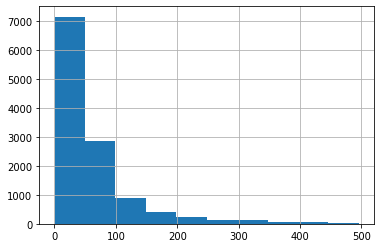

In [ ]:
red_pat_df[red_pat_df.los <= 500]['los'].hist()

In [ ]:
# Keep track of the patients who had at least 12 hours in the ICU
keep_stays = red_pat_df[red_pat_df.los >= 12]['stay_id'].values

In [ ]:
len(keep_stays)

11624

## Reduce the extracted dataframes to only have the ICU stays longer than 12 hours

In [ ]:
red_pat_df = red_pat_df[red_pat_df.stay_id.isin(keep_stays)].copy()
pat_vitals = pat_vitals[pat_vitals.stay_id.isin(keep_stays)].copy()
pat_bg = pat_bg[pat_bg.stay_id.isin(keep_stays)].copy()
pat_cbc = pat_cbc[pat_cbc.stay_id.isin(keep_stays)].copy()
pat_chem = pat_chem[pat_chem.stay_id.isin(keep_stays)].copy()
pat_coag = pat_coag[pat_coag.stay_id.isin(keep_stays)].copy()
pat_enz = pat_enz[pat_enz.stay_id.isin(keep_stays)].copy()
pat_gcs = pat_gcs[pat_gcs.stay_id.isin(keep_stays)].copy()
pat_uo = pat_uo[pat_uo.stay_id.isin(keep_stays)].copy()
pat_fluids = pat_fluids[pat_fluids.stay_id.isin(keep_stays)].copy()
pat_vaso = pat_vaso[pat_vaso.stay_id.isin(keep_stays)].copy()
pat_septic = pat_septic[pat_septic.stay_id.isin(keep_stays)].copy()
pat_vent = pat_vent[pat_vent.stay_id.isin(keep_stays)].copy()

In [ ]:
pat_septic.shape

(6208, 14)

## Determine the timing of observed events, measurements, and adminstrations with relation to ICU admission (should only be positive) and some presumed onset of Sepsis (following the Sepsis 3 protocol)

In [ ]:
pat_vitals['time_from_admission_h'] = (pat_vitals.charttime - pat_vitals.icu_intime).dt.total_seconds()/60/60
pat_bg['time_from_admission_h'] = (pat_bg.charttime - pat_bg.icu_intime).dt.total_seconds()/60/60
pat_cbc['time_from_admission_h'] = (pat_cbc.charttime - pat_cbc.icu_intime).dt.total_seconds()/60/60
pat_chem['time_from_admission_h'] = (pat_chem.charttime - pat_chem.icu_intime).dt.total_seconds()/60/60
pat_coag['time_from_admission_h'] = (pat_coag.charttime - pat_coag.icu_intime).dt.total_seconds()/60/60
pat_enz['time_from_admission_h'] = (pat_enz.charttime - pat_enz.icu_intime).dt.total_seconds()/60/60
pat_gcs['time_from_admission_h'] = (pat_gcs.charttime - pat_gcs.icu_intime).dt.total_seconds()/60/60
pat_uo['time_from_admission_h'] = (pat_uo.charttime - pat_uo.icu_intime).dt.total_seconds()/60/60
pat_fluids['starttime_from_admission_h'] = (pat_fluids.starttime - pat_fluids.icu_intime).dt.total_seconds()/60/60
pat_fluids['endtime_from_admission_h'] = (pat_fluids.endtime - pat_fluids.icu_intime).dt.total_seconds()/60/60
pat_vaso['starttime_from_admission_h'] = (pat_vaso.starttime - pat_vaso.icu_intime).dt.total_seconds()/60/60
pat_vaso['endtime_from_admission_h'] = (pat_vaso.endtime - pat_vaso.icu_intime).dt.total_seconds()/60/60
pat_vent['starttime_from_admission_h'] = (pat_vent.starttime - pat_vent.icu_intime).dt.total_seconds()/60/60
pat_vent['endtime_from_admission_h'] = (pat_vent.endtime - pat_vent.icu_intime).dt.total_seconds()/60/60

We need to identify the temporal relation of a measurement/observation is made with a presumed onset of sepsis (using the pat_septic table)

In [ ]:
pat_septic.head()

,subject_id,gender,dod,hadm_id,ethnicity,hospital_expire_flag,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,admission_age,suspected_infection_time,sepsis3
0,10002155,F,2131-03-10,28994087,WHITE,0,31090461,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-09-24 00:50:00,2130-09-27 22:13:41,1,82,2130-09-23 20:30:00,True
2,10003400,F,2137-09-02,20214994,BLACK/AFRICAN AMERICAN,0,32128372,Medical/Surgical Intensive Care Unit (MICU/SICU),2137-02-25 23:37:19,2137-03-10 21:29:36,1,75,2137-02-26 00:16:00,True
3,10004733,M,NaT,27411876,UNKNOWN,0,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 11:28:24,2174-12-12 20:03:01,1,51,2174-12-04 13:01:00,True
4,10006821,F,NaT,23295760,WHITE,0,38792772,Medical/Surgical Intensive Care Unit (MICU/SICU),2182-10-24 20:38:16,2182-10-26 06:02:42,1,61,2182-10-24 21:56:00,True
5,10015931,M,2177-03-29,22130791,WHITE,1,37093652,Medical/Surgical Intensive Care Unit (MICU/SICU),2177-03-24 21:48:07,2177-03-29 18:03:36,1,88,2177-03-26 05:06:00,True


In [ ]:
comb_vitals = pat_vitals.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_bg = pat_bg.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_cbc = pat_cbc.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_chem = pat_chem.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_coag = pat_coag.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_enz = pat_enz.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_gcs = pat_gcs.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_uo = pat_uo.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_fluids = pat_fluids.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_vaso = pat_vaso.merge(pat_septic[['stay_id', 'suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')
comb_vent = pat_vent.merge(pat_septic[['stay_id','suspected_infection_time']], how='outer', left_on='stay_id', right_on='stay_id')

In [ ]:
comb_vitals.columns

Index(['subject_id', 'gender', 'dod', 'hadm_id', 'ethnicity',
       'hospital_expire_flag', 'stay_id', 'first_careunit', 'icu_intime',
       'icu_outtime', 'icustay_seq', 'admission_age', 'height', 'weight',
       'charttime', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate',
       'temperature', 'spo2', 'glucose', 'time_from_admission_h',
       'suspected_infection_time'],
      dtype='object')

In [ ]:
comb_vitals['time_from_sepsis_h'] = (comb_vitals.charttime - comb_vitals.suspected_infection_time).dt.total_seconds()/60/60
comb_bg['time_from_sepsis_h'] = (comb_bg.charttime - comb_bg.suspected_infection_time).dt.total_seconds()/60/60
comb_cbc['time_from_sepsis_h'] = (comb_cbc.charttime - comb_cbc.suspected_infection_time).dt.total_seconds()/60/60
comb_chem['time_from_sepsis_h'] = (comb_chem.charttime - comb_chem.suspected_infection_time).dt.total_seconds()/60/60
comb_coag['time_from_sepsis_h'] = (comb_coag.charttime - comb_coag.suspected_infection_time).dt.total_seconds()/60/60
comb_enz['time_from_sepsis_h'] = (comb_enz.charttime - comb_enz.suspected_infection_time).dt.total_seconds()/60/60
comb_gcs['time_from_sepsis_h'] = (comb_gcs.charttime - comb_gcs.suspected_infection_time).dt.total_seconds()/60/60
comb_uo['time_from_sepsis_h'] = (comb_uo.charttime - comb_uo.suspected_infection_time).dt.total_seconds()/60/60
comb_fluids['starttime_from_sepsis_h'] = (comb_fluids.starttime - comb_fluids.suspected_infection_time).dt.total_seconds()/60/60
comb_fluids['endtime_from_sepsis_h'] = (comb_fluids.endtime - comb_fluids.suspected_infection_time).dt.total_seconds()/60/60
comb_vaso['starttime_from_sepsis_h'] = (comb_vaso.starttime - comb_vaso.suspected_infection_time).dt.total_seconds()/60/60
comb_vaso['endtime_from_sepsis_h'] = (comb_vaso.endtime - comb_vaso.suspected_infection_time).dt.total_seconds()/60/60
comb_vent['starttime_from_sepsis_h'] = (comb_vent.starttime - comb_vent.suspected_infection_time).dt.total_seconds()/60/60
comb_vent['endtime_from_sepsis_h'] = (comb_vent.endtime - comb_vent.suspected_infection_time).dt.total_seconds()/60/60

## Now, extract the patients who can be assumed to be hypotensive 
(7+ MAP/MBP measures less than 65 mmHg)

In [ ]:
MAP_FILTER_THRESH = 65

In [ ]:
hyp_df = comb_vitals[['stay_id','mbp','time_from_admission_h']]

In [ ]:
hyp_df.head()

,stay_id,mbp,time_from_admission_h
0,31205490,NaN,0.027222
1,31205490,59.0,0.127222
2,31205490,70.0,0.177222
3,31205490,81.0,1.127222
4,31205490,NaN,1.627222


In [ ]:
temp = hyp_df[hyp_df.stay_id==31205490].copy()

In [ ]:
sum((temp.mbp < MAP_FILTER_THRESH) & (temp.time_from_admission_h <= 72))

9

In [ ]:
hyp_grp = hyp_df.groupby('stay_id').apply(lambda x: sum((x.mbp <= MAP_FILTER_THRESH) & (x.time_from_admission_h <= 72)) )
hyp_grp

stay_id
30001396     0
30002521     1
30004568     1
30004823     0
30005160     2
            ..
39992167    35
39993265    14
39995630     0
39996123    13
39998871     4
Length: 11624, dtype: int64

In [ ]:
hypotensive_patients = hyp_grp[hyp_grp >= 7].index

In [ ]:
hypotensive_patients[:10]

Int64Index([30010785, 30018144, 30019367, 30020307, 30020330, 30026250,
            30028516, 30031116, 30031418, 30031915],
           dtype='int64', name='stay_id')

In [ ]:
# Getting the mortality rate (within the first 72 hours (+48h) of admission to the ICU)
hypo_df = comb_vitals[comb_vitals.stay_id.isin(hypotensive_patients)].copy()

In [ ]:
hypo_df.shape

(852157, 26)

In [ ]:
# Just getting the first row for each stay ID
hypo_df = hypo_df.groupby('stay_id').agg('first').reset_index()

In [ ]:
# Mortality rate of Hypotensive patients (in the first 72 hours, without accounting for whether they have become septic)
sum(((hypo_df.dod - hypo_df.icu_intime).dt.total_seconds()/60/60) <= 72+48) / len(hypotensive_patients)

0.09853168469860897

In [ ]:
hypo_df_nonseptic = hypo_df[~hypo_df.stay_id.isin(pat_septic.stay_id.unique())]
hypo_df_nonseptic.shape

(1553, 26)

In [ ]:
# Mortality rate of Non-septic Hypotensive patients (in the first 72 hours)
sum(((hypo_df_nonseptic.dod - hypo_df_nonseptic.icu_intime).dt.total_seconds()/60/60) <= 72+48) / hypo_df_nonseptic.shape[0]

0.07405022537025113

In [ ]:
comb_grp = comb_vitals.groupby('stay_id').agg('first').reset_index()

In [ ]:
septic_df = comb_grp[comb_grp.stay_id.isin(pat_septic.stay_id.unique())]
septic_df.shape

(6208, 26)

In [ ]:
# Mortality rate of septic patients (on their first stay in the MICU, at least 48 hours after discharge)
sum(((septic_df.dod - septic_df.icu_outtime).dt.total_seconds()/60/60) <= 48) / septic_df.shape[0]

0.13530927835051546

In [ ]:
hypo_df_AND_septic = hypo_df[hypo_df.stay_id.isin(pat_septic.stay_id.unique())]
hypo_df_AND_septic.shape

(3623, 26)

In [ ]:
# Mortality rate of Hypotensive who were also Septic (in the first 72 hours)
sum(((hypo_df_AND_septic.dod - hypo_df_AND_septic.icu_intime).dt.total_seconds()/60/60) <= 72+48) / hypo_df_AND_septic.shape[0]

0.10902566933480541

### [SKIP!] Investigate the overlapping region between septic and hypotensive patients... 

Right now this is going to look at how early the presumed onset of sepsis occurs in relation to ICU admission. We will need to eliminate from consideration those patients in this intersection that have overlapping windows (first 72h for HYP, -24h to +48h for SEP) because they'll be considered more fully in the Septic subpopulation (maybe?).

In [ ]:
temp = hypo_df_AND_septic[['subject_id','stay_id', 'dod', 'icu_intime', 'suspected_infection_time']].copy()

In [ ]:
temp['presumed_onset_from_admission'] = (temp.suspected_infection_time - temp.icu_intime).dt.total_seconds()/60/60

In [ ]:
temp.head()

,subject_id,stay_id,dod,icu_intime,suspected_infection_time,presumed_onset_from_admission
0,14992874,30010785,NaT,2171-08-29 17:10:00,2171-08-29 15:00:00,-2.166667
2,11638303,30019367,2146-06-01,2146-05-25 20:05:08,2146-05-25 22:00:00,1.914444
3,15368003,30020307,NaT,2131-08-29 18:25:56,2131-08-29 21:00:00,2.567778
4,15884351,30020330,NaT,2196-05-15 19:23:45,2196-05-15 20:00:00,0.604167
5,11173428,30026250,2132-12-17,2131-11-21 18:57:00,2131-11-21 15:15:00,-3.700000


In [ ]:
sum(temp.presumed_onset_from_admission >= 72+24)

20

So we have 20 patients who were hypotensive and then become septic enough afterward to where we can include them in the Hypotensive AND not septic cohort... The rest of them will be included in the septic cohort

In [ ]:
temp2 = temp[temp.presumed_onset_from_admission >= 72+24].copy()

In [ ]:
temp2

,subject_id,stay_id,dod,icu_intime,suspected_infection_time,presumed_onset_from_admission
58,15983568,30128855,NaT,2173-01-03 11:30:50,2173-01-09 12:06:00,144.586111
92,19351106,30187303,NaT,2130-08-01 15:35:46,2130-08-07 07:45:00,136.153889
326,19198743,30595022,NaT,2153-01-13 16:10:21,2153-01-17 19:58:00,99.794167
1225,14065824,32295004,NaT,2146-08-27 23:51:31,2146-09-03 20:59:00,165.124722
1267,17036580,32379793,2188-05-19,2188-05-01 22:54:00,2188-05-07 03:00:00,124.100000
1280,13956197,32404280,2169-11-02,2164-03-02 12:33:18,2164-03-06 19:57:00,103.395000
1362,17394776,32556356,2189-05-25,2188-10-23 14:59:06,2188-10-28 23:36:00,128.615000
1550,16343751,32900830,NaT,2117-03-26 20:24:00,2117-04-11 15:24:00,379.000000
1667,13689758,33141213,NaT,2130-11-15 23:31:58,2130-11-29 14:00:00,326.467222
1889,14124506,33525901,NaT,2153-05-02 17:55:00,2153-05-07 03:40:00,105.750000


In [ ]:
temp2.shape

(20, 6)

In [ ]:
presepsis_hyp_stays = temp2.stay_id.unique()

In [ ]:
hypo_df_nonseptic = hypo_df[(~hypo_df.stay_id.isin(pat_septic.stay_id.unique())) | hypo_df.stay_id.isin(presepsis_hyp_stays)]
hypo_df_nonseptic.shape

(1601, 55)

In [ ]:
# Mortality rate of Non-septic Hypotensive patients (in the first 72 hours)
sum(((hypo_df_nonseptic.dod - hypo_df_nonseptic.icu_intime).dt.total_seconds()/60/60) <= 72+48) / hypo_df_nonseptic.shape[0]

0.07807620237351655

## Reduce our dataframes to only contain the data from these ~8000 stays

In [ ]:
hypotensive_subcohort = hypo_df_nonseptic.stay_id.unique()
septic_subcohort = septic_df.stay_id.unique()

In [ ]:
np.save(f"{OUTPUT_DIR}/hypo_subcohort.npy", hypotensive_subcohort)
np.save(f"{OUTPUT_DIR}/sep_subcohort.npy", septic_subcohort)
np.save(f"{OUTPUT_DIR}/presepsis_ahe_subcohort.npy", presepsis_hyp_stays)

In [ ]:
len(hypotensive_subcohort), len(septic_subcohort)

(1553, 6208)

In [ ]:
print(f'Total number of trajectories in preliminary cohort: {len(hypotensive_subcohort) + len(septic_subcohort)}')

Total number of trajectories in preliminary cohort: 7761


In [ ]:
cohort_stayids = np.concatenate((hypotensive_subcohort, septic_subcohort))

In [ ]:
red_pat_df = red_pat_df[red_pat_df.stay_id.isin(cohort_stayids)].copy()
vitals_df = comb_vitals[comb_vitals.stay_id.isin(cohort_stayids)].copy()
bg_df = comb_bg[comb_bg.stay_id.isin(cohort_stayids)].copy()
cbc_df = comb_cbc[comb_cbc.stay_id.isin(cohort_stayids)].copy()
chem_df = comb_chem[comb_chem.stay_id.isin(cohort_stayids)].copy()
coag_df = comb_coag[comb_coag.stay_id.isin(cohort_stayids)].copy()
enz_df = comb_enz[comb_enz.stay_id.isin(cohort_stayids)].copy()
gcs_df = comb_gcs[comb_gcs.stay_id.isin(cohort_stayids)].copy()
uo_df = comb_uo[comb_uo.stay_id.isin(cohort_stayids)].copy()
fluids_df = comb_fluids[comb_fluids.stay_id.isin(cohort_stayids)].copy()
vaso_df = comb_vaso[comb_vaso.stay_id.isin(cohort_stayids)].copy()
vent_df = comb_vent[comb_vent.stay_id.isin(cohort_stayids)].copy()

In [ ]:
vitals_df.shape

(1169098, 26)

In [ ]:
fluids_df.shape

(253347, 15)

In [ ]:
vaso_df.shape

(76473, 26)

In [ ]:
vent_df.shape

(8932, 15)

## Aggregate data by hour 
 - from either admission (AHE) or based on presumed sepsis onset

In [ ]:
def define_bloc(row):
  """This function receives a row from a dataframe, and based on stay_id,
  the bloc will be determined by either the time from admission or time from onset"""

  if row['stay_id'] in septic_subcohort:
    return np.ceil(row['time_from_sepsis_h'])
  else:
    return np.ceil(row['time_from_admission_h'])

def define_start_bloc(row):
  """For the time-based administrations, define the blocks of time the measure started"""
  if row['stay_id'] in septic_subcohort:
    return np.ceil(row['starttime_from_sepsis_h'])
  else:
    return np.ceil(row['starttime_from_admission_h'])

def define_end_bloc(row):
  """For the time-based administrations, define the blocks of time the measure ended"""
  if row['stay_id'] in septic_subcohort:
    return np.ceil(row['endtime_from_sepsis_h'])
  else:
    return np.ceil(row['endtime_from_admission_h'])

In [ ]:
vitals_df['bloc'] = vitals_df.apply(define_bloc, axis=1)
bg_df['bloc'] = bg_df.apply(define_bloc, axis=1)
cbc_df['bloc'] = cbc_df.apply(define_bloc, axis=1)
chem_df['bloc'] = chem_df.apply(define_bloc, axis=1)
coag_df['bloc'] = coag_df.apply(define_bloc, axis=1)
enz_df['bloc'] = enz_df.apply(define_bloc, axis=1)
gcs_df['bloc'] = gcs_df.apply(define_bloc, axis=1)
uo_df['bloc'] = uo_df.apply(define_bloc, axis=1)

In [ ]:
fluids_df['start_bloc'] = fluids_df.apply(define_start_bloc, axis=1)
fluids_df['end_bloc'] = fluids_df.apply(define_end_bloc, axis=1)
vaso_df['start_bloc'] = vaso_df.apply(define_start_bloc, axis=1)
vaso_df['end_bloc'] = vaso_df.apply(define_end_bloc, axis=1)
vent_df['start_bloc'] = vent_df.apply(define_start_bloc, axis=1)
vent_df['end_bloc'] = vent_df.apply(define_end_bloc, axis=1)

In [ ]:
temp_sep = septic_subcohort[10:15]
temp_ahe = hypotensive_subcohort[10:15]

temp_ids = np.concatenate((temp_sep, temp_ahe))

temp_vitals = vitals_df[vitals_df.stay_id.isin(temp_ids)]
temp_bg = bg_df[bg_df.stay_id.isin(temp_ids)]

In [ ]:
vitals_df.shape

(1169098, 27)

In [ ]:
features = vitals_df.merge(bg_df[['stay_id', 'bloc', 'so2','po2','pco2','fio2','pao2fio2ratio','ph','baseexcess','chloride','calcium','potassium','sodium','lactate']], how='outer', on=['stay_id','bloc'])

In [ ]:
features = features.merge(cbc_df[['stay_id','bloc','hematocrit','hemoglobin', 'platelet', 'wbc']], how='outer', on=['stay_id','bloc'])

In [ ]:
features = features.merge(chem_df[['stay_id','bloc','albumin', 'aniongap','bun', 'creatinine', 'bicarbonate']], how='outer', on=['stay_id', 'bloc'])

In [ ]:
features = features.merge(coag_df[['stay_id','bloc', 'inr', 'pt', 'ptt']], how='outer', on=['stay_id','bloc'])

In [ ]:
features = features.merge(enz_df[['stay_id','bloc','alt', 'ast', 'bilirubin']], how='outer', on=['stay_id', 'bloc'])

In [ ]:
features = features.merge(gcs_df[['stay_id','bloc','gcs']], how='outer', on=['stay_id', 'bloc'])

In [ ]:
features = features.merge(uo_df[['stay_id','bloc','UO']], how='outer', on=['stay_id', 'bloc'])

In [ ]:
features.shape

(2185022, 56)

In [ ]:
# Save off the dataframes
red_pat_df.to_csv(f"{OUTPUT_DIR}/patient_lookup.csv", index=False, compression="gzip")
features.to_csv(f"{OUTPUT_DIR}/combined_features.csv", index=False, compression="gzip")
fluids_df.to_csv(f"{OUTPUT_DIR}/combined_fluids.csv", index=False, compression="gzip")
vaso_df.to_csv(f"{OUTPUT_DIR}/combined_vasopressors.csv", index=False, compression="gzip")
vent_df.to_csv(f"{OUTPUT_DIR}/combined_ventilation.csv", index=False, compression="gzip")

## Load the combined dataframes and patient IDs belonging to our subcohorts

In [ ]:
red_pat = pd.read_csv(f"{OUTPUT_DIR}/patient_lookup.csv", compression="gzip")
features = pd.read_csv(f"{OUTPUT_DIR}/combined_features.csv", compression="gzip")
fluids_df = pd.read_csv(f"{OUTPUT_DIR}/combined_fluids.csv", compression="gzip")
vaso_df = pd.read_csv(f"{OUTPUT_DIR}/combined_vasopressors.csv", compression="gzip")
vent_df = pd.read_csv(f"{OUTPUT_DIR}/combined_ventilation.csv", compression="gzip")

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2882: DtypeWarning: Columns (1,2,4,7,8,9,14,24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
hypotensive_subcohort = np.load(f"{OUTPUT_DIR}/hypo_subcohort.npy")
septic_subcohort = np.load(f"{OUTPUT_DIR}/sep_subcohort.npy")
presepsis_hyp_stays = np.load(f"{OUTPUT_DIR}/presepsis_ahe_subcohort.npy")

In [ ]:
feat_cols = ['bloc', 'stay_id', 'admission_age', 'height', 'weight', 'gender', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate',
       'temperature', 'spo2', 'glucose', 'so2', 'po2', 'pco2', 'fio2', 'pao2fio2ratio', 'ph', 'baseexcess', 'chloride',
       'calcium', 'potassium', 'sodium', 'lactate', 'hematocrit', 'hemoglobin', 'platelet', 'wbc', 'albumin', 'aniongap', 'bun', 'creatinine',
       'bicarbonate', 'inr', 'pt', 'ptt', 'alt', 'ast', 'bilirubin', 'gcs', 'UO', 'time_from_sepsis_h']

In [ ]:
admin_cols = ['stay_id','admission_age', 'height', 'weight','gender']
vital_cols = ['heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate', 'temperature', 'spo2', 'glucose']
meas_cols = ['so2', 'po2', 'pco2', 'fio2', 'pao2fio2ratio', 'ph', 'baseexcess', 'chloride',
       'calcium', 'potassium', 'sodium', 'lactate', 'hematocrit', 'hemoglobin', 'platelet', 
       'wbc', 'albumin', 'aniongap', 'bun', 'creatinine','bicarbonate', 'inr', 'pt', 'ptt', 
       'alt', 'ast', 'bilirubin', 'gcs', 'UO']

In [ ]:
def downselect_rows(group):
  """ 
  This helper function fills gaps in the observed data, placing rows of NaNs between recorded hours
  We also discard all rows outside the relevant windows we're interested in, forward fill the 
  lab measurements (following advice from L. Celi), then remove extraneous rows that 
  precede or directly follow the core center of the recorded data.
  """
  if group.time_from_sepsis_h.isna().all():  # all rows are null, patient is not septic
    low, high = 0, 72
  else:
    low, high = -24, 48

  # First remove all rows outside the relevant window
  group = group[(group.bloc>=low)&(group.bloc<=high)]
  # Aggregate information in columns for duplicate 'blocs'
  agg_a = {k:'first' for k in admin_cols}
  agg_b = {k:'mean' for k in group.columns if k not in admin_cols}
  agg_d = {**agg_a, **agg_b}
  group = group.groupby('bloc', as_index=False).agg(agg_d)
  # Now fill in the missing rows for the window
  group = group.set_index('bloc')
  group = group.reindex(np.arange(low,high+1)).reset_index()
  # Fill forward identifying information for the patient as well as all lab measurements
  group.loc[:,admin_cols] = group.loc[:, admin_cols].ffill().bfill()
  # group.loc[:,meas_cols] = group.loc[:, meas_cols].ffill()
  # Need to find a way to remove unneeded rows (where all vitals are not recorded in the 6 hours prior)
  missing_blocs = group[group[vital_cols].isna().all(axis=1)]['bloc']  # The blocs that do not have a vital sign recorded
  gap_blocs = missing_blocs.diff().fillna(0.0) # Computes the number of hours since the full vital sign features were missing (anything less than 6 should be removed)
  remove_blocs = missing_blocs[~(gap_blocs > 1)] # Ideally this will be 6... but it might make sense to just use this to clip off the empty beginnings and endings?
  # Remove the unneeded rows
  group_red = group[~group.bloc.isin(remove_blocs.values)]
  group_red = group_red.reset_index(drop=True).reset_index().rename(columns={'index': 'timestep'})
  return group_red

In [ ]:
def define_death(row):
  """
  Using different definitions of mortality for the separate subpopulations. We don't
  want to confound possible Hypotensive patient deaths to be confounded with complications
  that may have arisen later in the ICU stay
  """
  if row['stay_id'] in septic_subcohort:
    return ((row.dod - row.icu_outtime).dt.total_seconds()/60/60) <= 48  # Death occurs within 48h of being in ICU
  else:
    return ((row.dod - row.icu_intime).dt.total_seconds()/60/60) <= (72+48)  # Death occurs within 48h of the end of the AHE early observation window

In [ ]:
red_pat_df = features[['stay_id','dod','hospital_expire_flag','suspected_infection_time','icu_intime','icu_outtime']].groupby('stay_id').agg('first').reset_index()

In [ ]:
red_pat_df['icu_intime'] = pd.to_datetime(red_pat_df['icu_intime'])
red_pat_df['icu_outtime'] = pd.to_datetime(red_pat_df['icu_outtime'])
red_pat_df['dod'] = pd.to_datetime(red_pat_df['dod'])

In [ ]:
sep_red_pat = red_pat_df[red_pat_df.stay_id.isin(septic_subcohort)].copy()
hyp_red_pat = red_pat_df[~red_pat_df.stay_id.isin(septic_subcohort)].copy()

In [ ]:
hyp_mortality = ((hyp_red_pat.dod - hyp_red_pat.icu_intime).dt.total_seconds()/60/60) <= (72+48)
sep_mortality = ((sep_red_pat.dod - sep_red_pat.icu_outtime).dt.total_seconds()/60/60) <= 48

In [ ]:
red_pat_df['mortality'] = False

In [ ]:
red_pat_df.loc[red_pat_df.stay_id.isin(septic_subcohort), 'mortality'] = sep_mortality.values
red_pat_df.loc[red_pat_df.stay_id.isin(hypotensive_subcohort), 'mortality'] = hyp_mortality.values

In [ ]:
# Separate overlap of septic AND AHE patients... There are ~20 of them...
# We don't want to downselect the rows of these patients as they have a relevant 
# Hypotensive period in their first 72 hours that doesn't overlap with the supposed
# Sepsis window (24h before presumed onset to 48h afterward)
overlap_feats = features[features.stay_id.isin(presepsis_hyp_stays)].copy()
features = features[~features.stay_id.isin(presepsis_hyp_stays)].copy()

In [ ]:
len(overlap_feats.stay_id.unique())

20

In [ ]:
len(features.stay_id.unique())

7741

In [ ]:
agg_feats_df = features.groupby('stay_id')[admin_cols+vital_cols+meas_cols+['time_from_sepsis_h','bloc']].apply(downselect_rows).reset_index(drop=True)

After this aggregation we need to add back in relevant features from the patient lookup dataframe that went missing...

We also need to map the gender column to a binary variable

In [ ]:
agg_feats_df.shape

(312101, 45)

In [ ]:
# Add the mortality column in!
agg_feats_df = agg_feats_df.merge(red_pat_df[['stay_id','mortality']], how='left', on='stay_id')

In [ ]:
overlap_feats = overlap_feats.merge(red_pat_df[['stay_id','mortality']], how='left', on='stay_id')

In [ ]:
agg_feats_df.columns

Index(['timestep', 'bloc', 'stay_id', 'admission_age', 'height', 'weight',
       'gender', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate', 'temperature',
       'spo2', 'glucose', 'so2', 'po2', 'pco2', 'fio2', 'pao2fio2ratio', 'ph',
       'baseexcess', 'chloride', 'calcium', 'potassium', 'sodium', 'lactate',
       'hematocrit', 'hemoglobin', 'platelet', 'wbc', 'albumin', 'aniongap',
       'bun', 'creatinine', 'bicarbonate', 'inr', 'pt', 'ptt', 'alt', 'ast',
       'bilirubin', 'gcs', 'UO', 'time_from_sepsis_h', 'mortality'],
      dtype='object')

## Now let's get the Mechanical Ventilation flag incorporated

In [ ]:
vent_df.head()

,subject_id,hadm_id,stay_id,first_careunit,icu_intime,icu_outtime,icustay_seq,starttime,endtime,ventilation_status,starttime_from_admission_h,endtime_from_admission_h,suspected_infection_time,starttime_from_sepsis_h,endtime_from_sepsis_h,start_bloc,end_bloc
0,10003400.0,20214994.0,32128372,Medical/Surgical Intensive Care Unit (MICU/SICU),2137-02-25 23:37:19,2137-03-10 21:29:36,1.0,2137-02-25 23:37:00,2137-02-26 08:00:00,InvasiveVent,-0.005278,8.378056,2137-02-26 00:16:00,-0.650000,7.733333,-0.0,8.0
1,10015931.0,22130791.0,37093652,Medical/Surgical Intensive Care Unit (MICU/SICU),2177-03-24 21:48:07,2177-03-29 18:03:36,1.0,2177-03-26 05:30:00,2177-03-26 08:00:00,InvasiveVent,31.698056,34.198056,2177-03-26 05:06:00,0.400000,2.900000,1.0,3.0
2,10017531.0,22580355.0,35526828,Medical/Surgical Intensive Care Unit (MICU/SICU),2159-09-22 19:30:55,2159-10-24 14:57:16,1.0,2159-10-21 19:05:00,2159-10-22 08:00:00,InvasiveVent,695.568056,708.484722,2159-09-22 20:00:00,695.083333,708.000000,696.0,708.0
3,10017531.0,22580355.0,35526828,Medical/Surgical Intensive Care Unit (MICU/SICU),2159-09-22 19:30:55,2159-10-24 14:57:16,1.0,2159-10-17 14:10:00,2159-10-18 12:00:00,InvasiveVent,594.651389,616.484722,2159-09-22 20:00:00,594.166667,616.000000,595.0,616.0
4,10017531.0,22580355.0,35526828,Medical/Surgical Intensive Care Unit (MICU/SICU),2159-09-22 19:30:55,2159-10-24 14:57:16,1.0,2159-09-30 22:00:00,2159-10-17 10:43:00,InvasiveVent,194.484722,591.201389,2159-09-22 20:00:00,194.000000,590.716667,194.0,591.0


In [ ]:
vent_copy = vent_df.copy()

In [ ]:
vent_copy.end_bloc.isna().any()
vent_copy = vent_copy.dropna(subset=['start_bloc', 'end_bloc'])
vent_copy.shape

(5124, 17)

In [ ]:
# Expand the rows for each hour that the ventilator is on!
df1 = pd.concat([pd.Series(r.stay_id,np.arange(r.start_bloc, r.end_bloc+1)) 
                 for r in vent_copy.itertuples()]).reset_index()

In [ ]:
df1.columns = ['bloc', 'stay_id']
df1['ventilation'] = 1.

In [ ]:
# Add in ventilation information for each stay_id
agg_feats_df = agg_feats_df.merge(df1, how='left', on=['stay_id', 'bloc'])
agg_feats_df.drop_duplicates(inplace=True)

In [ ]:
agg_vent = agg_feats_df.ventilation.fillna(0.)
agg_feats_df['ventilation'] = agg_vent

In [ ]:
overlap_feats = overlap_feats.merge(df1, how='left', on=['stay_id','bloc'])
overlap_feats.drop_duplicates(inplace=True)

In [ ]:
overlap_vent = overlap_feats.ventilation.fillna(0.)
overlap_feats['ventilation'] = overlap_vent

In [ ]:
# Now let's convert the gender and mortality columns to numerical values
agg_feats_df['mortality'] = 1.0*agg_feats_df['mortality']
overlap_feats['mortality'] = 1.0*overlap_feats['mortality']

agg_feats_df['gender'] = agg_feats_df['gender'].map({'M': 1, 'F': 0})
overlap_feats['gender'] = overlap_feats['gender'].map({'M': 1, 'F': 0})

In [ ]:
agg_feats_df.head()

,timestep,bloc,stay_id,admission_age,height,weight,gender,heart_rate,sbp,dbp,...,pt,ptt,alt,ast,bilirubin,gcs,UO,time_from_sepsis_h,mortality,ventilation
0,0,-8,30004823.0,53.0,175.0,91.0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,250.0,-8.000000,0.0,0.0
1,1,-7,30004823.0,53.0,175.0,91.0,1,88.5,163.0,89.0,...,NaN,NaN,NaN,NaN,NaN,15.0,NaN,-7.410000,0.0,1.0
2,2,-6,30004823.0,53.0,175.0,91.0,1,86.0,119.0,79.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.491667,0.0,1.0
3,3,-5,30004823.0,53.0,175.0,91.0,1,87.0,140.0,81.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.491667,0.0,1.0
4,4,-4,30004823.0,53.0,175.0,91.0,1,95.0,133.0,79.0,...,25.0,35.2,NaN,NaN,NaN,NaN,NaN,-4.433333,0.0,1.0


In [ ]:
agg_feats_df[agg_feats_df.stay_id==30004823]

,timestep,bloc,stay_id,admission_age,height,weight,gender,heart_rate,sbp,dbp,...,pt,ptt,alt,ast,bilirubin,gcs,UO,time_from_sepsis_h,mortality,ventilation
0,0,-8,30004823.0,53.0,175.0,91.0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,250.0,-8.000000,0.0,0.0
1,1,-7,30004823.0,53.0,175.0,91.0,1,88.5,163.0,89.0,...,NaN,NaN,NaN,NaN,NaN,15.0,NaN,-7.410000,0.0,1.0
2,2,-6,30004823.0,53.0,175.0,91.0,1,86.0,119.0,79.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.491667,0.0,1.0
3,3,-5,30004823.0,53.0,175.0,91.0,1,87.0,140.0,81.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.491667,0.0,1.0
4,4,-4,30004823.0,53.0,175.0,91.0,1,95.0,133.0,79.0,...,25.0,35.2,NaN,NaN,NaN,NaN,NaN,-4.433333,0.0,1.0
5,5,-3,30004823.0,53.0,175.0,91.0,1,96.0,174.0,94.0,...,NaN,NaN,NaN,NaN,NaN,NaN,250.0,-3.491667,0.0,1.0
6,6,-2,30004823.0,53.0,175.0,91.0,1,82.0,120.0,78.0,...,NaN,NaN,NaN,NaN,NaN,NaN,200.0,-2.491667,0.0,1.0
7,7,-1,30004823.0,53.0,175.0,91.0,1,80.0,136.0,84.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.491667,0.0,1.0
8,8,0,30004823.0,53.0,175.0,91.0,1,71.0,136.0,81.0,...,NaN,NaN,NaN,NaN,NaN,15.0,NaN,-0.491667,0.0,1.0
9,9,1,30004823.0,53.0,175.0,91.0,1,76.0,139.0,84.0,...,NaN,NaN,NaN,NaN,NaN,NaN,250.0,0.508333,0.0,1.0


In [ ]:
# Save off temporary progress!!
agg_feats_df.to_csv(f"{OUTPUT_DIR}/aggregated_patient_features.csv", index=False, compression="gzip")
overlap_feats.to_csv(f"{OUTPUT_DIR}/overlapping_patients_features.csv", index=False, compression="gzip")

In [ ]:
# Load these dataframes!
agg_feats_df = pd.read_csv(f"{OUTPUT_DIR}/aggregated_patient_features.csv", compression="gzip")
overlap_feats = pd.read_csv(f"{OUTPUT_DIR}/overlapping_patients_features.csv", compression="gzip")

In [ ]:
red_pat.columns

Index(['stay_id', 'subject_id', 'hadm_id', 'dod', 'hospital_expire_flag',
       'icu_intime', 'icu_outtime', 'los'],
      dtype='object')

In [ ]:
overlap_feats.columns

Index(['subject_id', 'gender', 'dod', 'hadm_id', 'ethnicity',
       'hospital_expire_flag', 'stay_id', 'first_careunit', 'icu_intime',
       'icu_outtime', 'icustay_seq', 'admission_age', 'height', 'weight',
       'charttime', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate',
       'temperature', 'spo2', 'glucose', 'time_from_admission_h',
       'suspected_infection_time', 'time_from_sepsis_h', 'bloc', 'so2', 'po2',
       'pco2', 'fio2', 'pao2fio2ratio', 'ph', 'baseexcess', 'chloride',
       'calcium', 'potassium', 'sodium', 'lactate', 'hematocrit', 'hemoglobin',
       'platelet', 'wbc', 'albumin', 'aniongap', 'bun', 'creatinine',
       'bicarbonate', 'inr', 'pt', 'ptt', 'alt', 'ast', 'bilirubin', 'gcs',
       'UO', 'mortality', 'ventilation'],
      dtype='object')

In [ ]:
overlap_feats['icu_intime'] = pd.to_datetime(overlap_feats['icu_intime'])
overlap_feats['icu_outtime'] = pd.to_datetime(overlap_feats['icu_outtime'])
overlap_feats['dod'] = pd.to_datetime(overlap_feats['dod'])
overlap_feats['suspected_infection_time'] = pd.to_datetime(overlap_feats['suspected_infection_time'])

In [ ]:
overlap_feats.stay_id.unique()

array([38690919, 35774845, 39107382, 35477442, 33141213, 32404280,
       32295004, 33525901, 35715575, 36969953, 35600501, 30128855,
       32900830, 32379793, 35729597, 37460334, 32556356, 30595022,
       30187303, 35733219])

In [ ]:
def downsample_overlap_feats(group):
  """This function is quite similar to 'downsample_rows' but has particular nuances 
  that need to be accounted for when handling the longer timeframes"""
  

  # First remove all rows outside the relevant window (from admission to 48h after presumed sepsis onset)
  group = group[(group.time_from_admission_h >= 0) & (group.time_from_sepsis_h <= 48)]
  group['bloc'] = group['bloc'] - group['bloc'].min()
  # Aggregate information in columns for duplicate 'blocs'
  agg_a = {k:'first' for k in admin_cols+['mortality', 'ventilation']}
  agg_b = {k:'mean' for k in group.columns if k not in admin_cols+['mortality', 'ventilation']}
  agg_d = {**agg_a, **agg_b}
  group = group.groupby('bloc', as_index=False).agg(agg_d)
  # Now fill in the missing rows for the window
  bloc_max = group.bloc.max()
  group = group.set_index('bloc')
  group = group.reindex(np.arange(0,bloc_max+1)).reset_index()
  # Fill forward identifying information for the patient as well as all lab measurements
  group.loc[:,admin_cols] = group.loc[:, admin_cols].ffill().bfill()
  # group.loc[:,meas_cols] = group.loc[:, meas_cols].ffill() # potentially add limit=6 so we only propagate for 6 hours?
  # Need to find a way to remove unneeded rows (where all vitals are not recorded in the 6 hours prior)
  missing_blocs = group[group[vital_cols].isna().all(axis=1)]['bloc']  # The blocs that do not have a vital sign recorded
  gap_blocs = missing_blocs.diff().fillna(0.0) # Computes the number of hours since the full vital sign features were missing (anything less than 6 should be removed)
  remove_blocs = missing_blocs[~(gap_blocs > 1)] # Ideally this will be 6... but it might make sense to just use this to clip off the empty beginnings and endings?
  # Remove the unneeded rows
  group_red = group[~group.bloc.isin(remove_blocs.values)]
  group_red = group_red.reset_index(drop=True).reset_index().rename(columns={'index': 'timestep'})
  return group_red

In [ ]:
grp_overlap = overlap_feats.groupby('stay_id')[admin_cols+vital_cols+meas_cols+['time_from_sepsis_h', 'time_from_admission_h','bloc', 'mortality','ventilation']].apply(downsample_overlap_feats).reset_index(drop=True)

In [ ]:
# Save off the aggregated overlapping features!
# grp_overlap.to_csv(f"{OUTPUT_DIR}/aggregated_overlapping_pat_features.csv", index=False, compression="gzip")
grp_overlap = pd.read_csv(f"{OUTPUT_DIR}/aggregated_overlapping_pat_features.csv", compression="gzip")

## Time to define the action space!

Combine the volumetric fluid and vasopressor volumes and establish a categorical set of variables...

In [ ]:
# We introduced rows of empties when adding the sepsis onset column... Remove these rows
vaso_df = vaso_df.dropna(how='all', subset=['dopamine', 'epinephrine', 'norepinephrine', 'phenylephrine','vasopressin', 'dobutamine', 'milrinone'])
fluids_df = fluids_df.dropna(how='all', subset=['amount', 'rate', 'tev'])

In [ ]:
# Separate out the overlapping patients from both the vaso and fluid DFs... 
# Will need to be handled differently
overlap_vaso = vaso_df[vaso_df.stay_id.isin(presepsis_hyp_stays)].copy()
overlap_fluids = fluids_df[fluids_df.stay_id.isin(presepsis_hyp_stays)].copy()

vaso_df = vaso_df[~vaso_df.stay_id.isin(presepsis_hyp_stays)].copy()
fluids_df = fluids_df[~fluids_df.stay_id.isin(presepsis_hyp_stays)].copy()

In [ ]:
vaso_df.shape, fluids_df.shape

((67160, 28), (250484, 17))

In [ ]:
vaso_df.columns

Index(['subject_id', 'gender', 'dod', 'hadm_id', 'ethnicity',
       'hospital_expire_flag', 'stay_id', 'first_careunit', 'icu_intime',
       'icu_outtime', 'icustay_seq', 'admission_age', 'starttime', 'endtime',
       'dopamine', 'epinephrine', 'norepinephrine', 'phenylephrine',
       'vasopressin', 'dobutamine', 'milrinone', 'starttime_from_admission_h',
       'endtime_from_admission_h', 'suspected_infection_time',
       'starttime_from_sepsis_h', 'endtime_from_sepsis_h', 'start_bloc',
       'end_bloc'],
      dtype='object')

In [ ]:
vaso_df['bloc'] = vaso_df['start_bloc']

In [ ]:
# Convert dosages to be equivalent to standard norepinephrine amounts 
# Following: https://github.com/MIT-LCP/mimic-code/blob/main/mimic-iv/concepts/medication/norepinephrine_equivalent_dose.sql

vaso_df['phenylephrine'] = vaso_df['phenylephrine'] / 10.
vaso_df['dopamine'] = vaso_df['dopamine'] / 100.
vaso_df['vasopressin'] = vaso_df['vasopressin']*2.5

In [ ]:
vaso_df['sum'] = vaso_df[['dopamine', 'epinephrine', 'norepinephrine', 'phenylephrine','vasopressin', 'dobutamine', 'milrinone']].sum(axis=1)

In [ ]:
vaso_output = np.zeros((10000000, 3))  # columns are 'stay_id', 'bloc', amount
idx = 0
for st_id in vaso_df.stay_id.unique():
  temp = vaso_df[vaso_df.stay_id==st_id]
  for row in range(temp.shape[0]):
    # st_id = temp.iloc[row]['stay_id']
    rate = temp.iloc[row]['sum']
    start = temp.iloc[row]['start_bloc']
    end = temp.iloc[row]['end_bloc']

    if start==end:
      vaso_output[idx, :] = np.array([st_id, start, rate])
      idx += 1
    else:
      for ts in np.arange(start, end):
        vaso_output[idx, :] = np.array([st_id, ts, rate])
        idx += 1

In [ ]:
vaso_output = np.delete(vaso_output, range(idx, len(vaso_output)), axis=0)

In [ ]:
vaso_output.shape

(139167, 3)

In [ ]:
split_vaso_df = pd.DataFrame(vaso_output, columns=['stay_id', 'bloc', 'vaso_amount']).groupby(['stay_id','bloc']).agg('max').reset_index()
split_vaso_df.head()

,stay_id,bloc,vaso_amount
0,30010785.0,8.0,0.100047
1,30010785.0,9.0,0.100047
2,30010785.0,10.0,0.050023
3,30010785.0,11.0,0.100047
4,30010785.0,12.0,0.075058


In [ ]:
agg_feats_df = agg_feats_df.merge(split_vaso_df, how='left', on=['stay_id','bloc'])

In [ ]:
fluids_df.columns

Index(['subject_id', 'stay_id', 'icu_intime', 'icu_outtime', 'starttime',
       'endtime', 'itemid', 'amount', 'rate', 'tev',
       'starttime_from_admission_h', 'endtime_from_admission_h',
       'suspected_infection_time', 'starttime_from_sepsis_h',
       'endtime_from_sepsis_h', 'start_bloc', 'end_bloc'],
      dtype='object')

In [ ]:
fluids_df.head()

,subject_id,stay_id,icu_intime,icu_outtime,starttime,endtime,itemid,amount,rate,tev,starttime_from_admission_h,endtime_from_admission_h,suspected_infection_time,starttime_from_sepsis_h,endtime_from_sepsis_h,start_bloc,end_bloc
0,18842317.0,30004823,2165-09-10 00:23:17,2165-09-11 20:27:10,2165-09-10 01:00:00,2165-09-10 04:36:00,225943.0,100.000,27.778,100.000,0.611944,4.211944,2165-09-10 08:00:00,-7.000000,-3.400000,-7.0,-3.0
1,18842317.0,30004823,2165-09-10 00:23:17,2165-09-11 20:27:10,2165-09-10 01:00:00,2165-09-10 04:36:00,225943.0,3.600,1.000,3.600,0.611944,4.211944,2165-09-10 08:00:00,-7.000000,-3.400000,-7.0,-3.0
2,18842317.0,30004823,2165-09-10 00:23:17,2165-09-11 20:27:10,2165-09-10 04:36:00,2165-09-10 05:17:00,225943.0,1.025,1.500,1.025,4.211944,4.895278,2165-09-10 08:00:00,-3.400000,-2.716667,-3.0,-2.0
3,18842317.0,30004823,2165-09-10 00:23:17,2165-09-11 20:27:10,2165-09-10 04:36:00,2165-09-10 05:16:00,225943.0,18.265,27.397,18.265,4.211944,4.878611,2165-09-10 08:00:00,-3.400000,-2.733333,-3.0,-2.0
4,18842317.0,30004823,2165-09-10 00:23:17,2165-09-11 20:27:10,2165-09-10 05:16:00,2165-09-10 06:22:00,225943.0,41.935,38.123,41.935,4.878611,5.978611,2165-09-10 08:00:00,-2.733333,-1.633333,-2.0,-1.0


In [ ]:
fluids_admin = np.zeros((10000000, 3))  # columns are 'stay_id', 'bloc', amount
idx = 0
for st_id in fluids_df.stay_id.unique():
  temp = fluids_df[fluids_df.stay_id==st_id]
  for row in range(temp.shape[0]):
    # st_id = temp.iloc[row]['stay_id']
    amount = temp.iloc[row]['amount']
    start = temp.iloc[row]['start_bloc']
    end = temp.iloc[row]['end_bloc']
    dt = end - start
    if dt == 0:
      rate = amount
    else:
      rate = amount / dt

    if start==end:
      fluids_admin[idx, :] = np.array([st_id, start, rate])
      idx += 1
    else:
      for ts in np.arange(start, end):
        fluids_admin[idx, :] = np.array([st_id, ts, rate])
        idx += 1

In [ ]:
fluids_admin = np.delete(fluids_admin, range(idx, len(fluids_admin)), axis=0)

In [ ]:
split_fluids_df = pd.DataFrame(fluids_admin, columns=['stay_id', 'bloc', 'fluids_amount']).groupby(['stay_id','bloc']).agg('sum').reset_index()
split_fluids_df.head()

,stay_id,bloc,fluids_amount
0,30004823.0,-7.0,25.90
1,30004823.0,-6.0,25.90
2,30004823.0,-5.0,25.90
3,30004823.0,-4.0,25.90
4,30004823.0,-3.0,19.29


In [ ]:
agg_feats_df = agg_feats_df.merge(split_fluids_df, how='left', on=['stay_id','bloc'])

In [ ]:
agg_feats_df['vaso_amount'] = agg_feats_df['vaso_amount'].fillna(0.0)
agg_feats_df['fluids_amount'] = agg_feats_df['fluids_amount'].fillna(0.0)

Repeat the above but for the overlapping subcohort vaso and fluids data

In [ ]:
# Adjust the timing for the `start_bloc` and `end_bloc` columns to be based on 
# the time from admission rather than time from presumed sepsis onset
overlap_vaso['start_bloc'] = np.ceil(overlap_vaso['starttime_from_admission_h'])
overlap_vaso['end_bloc'] = np.ceil(overlap_vaso['endtime_from_admission_h'])
overlap_fluids['start_bloc'] = np.ceil(overlap_fluids['starttime_from_admission_h'])
overlap_fluids['end_bloc'] = np.ceil(overlap_fluids['endtime_from_admission_h'])

In [ ]:
# Convert dosages to be equivalent to standard norepinephrine amounts 
# Following: https://github.com/MIT-LCP/mimic-code/blob/main/mimic-iv/concepts/medication/norepinephrine_equivalent_dose.sql

overlap_vaso['phenylephrine'] = overlap_vaso['phenylephrine'] / 10.
overlap_vaso['dopamine'] = overlap_vaso['dopamine'] / 100.
overlap_vaso['vasopressin'] = overlap_vaso['vasopressin']*2.5

In [ ]:
overlap_vaso['sum'] = overlap_vaso[['dopamine', 'epinephrine', 'norepinephrine', 'phenylephrine','vasopressin', 'dobutamine', 'milrinone']].sum(axis=1)

In [ ]:
vaso_output = np.zeros((10000000, 3))  # columns are 'stay_id', 'bloc', amount
idx = 0
for st_id in overlap_vaso.stay_id.unique():
  temp = overlap_vaso[overlap_vaso.stay_id==st_id]
  for row in range(temp.shape[0]):
    # st_id = temp.iloc[row]['stay_id']
    rate = temp.iloc[row]['sum']
    start = temp.iloc[row]['start_bloc']
    end = temp.iloc[row]['end_bloc']

    if start==end:
      vaso_output[idx, :] = np.array([st_id, start, rate])
      idx += 1
    else:
      for ts in np.arange(start, end):
        vaso_output[idx, :] = np.array([st_id, ts, rate])
        idx += 1

In [ ]:
vaso_output = np.delete(vaso_output, range(idx, len(vaso_output)), axis=0)

In [ ]:
split_vaso_df = pd.DataFrame(vaso_output, columns=['stay_id', 'bloc', 'vaso_amount']).groupby(['stay_id','bloc']).agg('max').reset_index()
split_vaso_df.head()

,stay_id,bloc,vaso_amount
0,30187303.0,1.0,0.300000
1,30187303.0,2.0,0.300000
2,30187303.0,3.0,0.100207
3,30187303.0,4.0,0.100207
4,30187303.0,5.0,0.080208


In [ ]:
overlap_vaso.shape

(798, 29)

In [ ]:
grp_overlap = grp_overlap.merge(split_vaso_df, how='left', on=['stay_id','bloc'])

Now for the fluids for the overlapping cohort

In [ ]:
fluids_admin = np.zeros((10000000, 3))  # columns are 'stay_id', 'bloc', amount
idx = 0
for st_id in overlap_fluids.stay_id.unique():
  temp = overlap_fluids[overlap_fluids.stay_id==st_id]
  for row in range(temp.shape[0]):
    # st_id = temp.iloc[row]['stay_id']
    amount = temp.iloc[row]['amount']
    start = temp.iloc[row]['start_bloc']
    end = temp.iloc[row]['end_bloc']
    dt = end - start
    if dt == 0:
      rate = amount
    else:
      rate = amount / dt

    if start==end:
      fluids_admin[idx, :] = np.array([st_id, start, rate])
      idx += 1
    else:
      for ts in np.arange(start, end):
        fluids_admin[idx, :] = np.array([st_id, ts, rate])
        idx += 1

In [ ]:
fluids_admin = np.delete(fluids_admin, range(idx, len(fluids_admin)), axis=0)

In [ ]:
split_fluids_df = pd.DataFrame(fluids_admin, columns=['stay_id', 'bloc', 'fluids_amount']).groupby(['stay_id','bloc']).agg('sum').reset_index()
split_fluids_df.head()

,stay_id,bloc,fluids_amount
0,30128855.0,2.0,501.367
1,30128855.0,3.0,500.499
2,30128855.0,4.0,0.499
3,30128855.0,5.0,0.499
4,30128855.0,6.0,0.499


In [ ]:
grp_overlap = grp_overlap.merge(split_fluids_df, how='left', on=['stay_id','bloc'])

In [ ]:
grp_overlap['vaso_amount'] = grp_overlap['vaso_amount'].fillna(0.0)
grp_overlap['fluids_amount'] = grp_overlap['fluids_amount'].fillna(0.0)

### With the fluids and vasopressor amounts in place, let's create a categorical action space following Gottesman, et al

In [ ]:
from scipy import stats

In [ ]:
agg_feats_df.head(10)

,timestep,bloc,stay_id,admission_age,height,weight,gender,heart_rate,sbp,dbp,...,alt,ast,bilirubin,gcs,UO,time_from_sepsis_h,mortality,ventilation,vaso_amount,fluids_amount
0,0,-8,30004823.0,53.0,175.0,91.0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,250.0,-8.000000,0.0,0.0,0.0,0.000000
1,1,-7,30004823.0,53.0,175.0,91.0,1,88.5,163.0,89.0,...,NaN,NaN,NaN,15.0,NaN,-7.410000,0.0,1.0,0.0,25.900000
2,2,-6,30004823.0,53.0,175.0,91.0,1,86.0,119.0,79.0,...,NaN,NaN,NaN,NaN,NaN,-6.491667,0.0,1.0,0.0,25.900000
3,3,-5,30004823.0,53.0,175.0,91.0,1,87.0,140.0,81.0,...,NaN,NaN,NaN,NaN,NaN,-5.491667,0.0,1.0,0.0,25.900000
4,4,-4,30004823.0,53.0,175.0,91.0,1,95.0,133.0,79.0,...,NaN,NaN,NaN,NaN,NaN,-4.433333,0.0,1.0,0.0,25.900000
5,5,-3,30004823.0,53.0,175.0,91.0,1,96.0,174.0,94.0,...,NaN,NaN,NaN,NaN,250.0,-3.491667,0.0,1.0,0.0,19.290000
6,6,-2,30004823.0,53.0,175.0,91.0,1,82.0,120.0,78.0,...,NaN,NaN,NaN,NaN,200.0,-2.491667,0.0,1.0,0.0,44.606333
7,7,-1,30004823.0,53.0,175.0,91.0,1,80.0,136.0,84.0,...,NaN,NaN,NaN,NaN,NaN,-1.491667,0.0,1.0,0.0,35.671333
8,8,0,30004823.0,53.0,175.0,91.0,1,71.0,136.0,81.0,...,NaN,NaN,NaN,15.0,NaN,-0.491667,0.0,1.0,0.0,35.018333
9,9,1,30004823.0,53.0,175.0,91.0,1,76.0,139.0,84.0,...,NaN,NaN,NaN,NaN,250.0,0.508333,0.0,1.0,0.0,48.224333


In [ ]:
# # How we did it for the Dead-ends septic cohort...
# # compute conversion factors using MIMIC data

# # fluid_cutoffs = [0,10,25,110,1e8] # 5 bins based on 25/50/75% quantiles of nonzeros
# # vaso_cutoffs = [0,0.05,0.1199,0.39897,1e8] # 5 bins based on 25/50/75% quantiles of nonzeros

# fc = agg_feats_df['fluids_amount'].values  # IV fluid
# fcr = stats.rankdata(fc[fc>0])/len(fc[fc>0]) # excludes zero fluid (will be action 1)
# iof = np.floor((fcr+0.2499999999)*4).astype(int) # converts fluid volume in 4 actions based on 0/25/50/75/100 quantiles
# a = agg_feats_df['fluids_amount'] > 0 # location of non-zero fluid in big matrix
# fo = np.ones(agg_feats_df.shape[0]) # array of ones, by default     
# fo[a] = iof + 1 # where more than zero fluid given: save actual action

# vc = agg_feats_df['vaso_amount'].values
# vcr = stats.rankdata(vc[vc>0])/len(vc[vc>0])
# iov = np.floor((vcr+0.249999999999)*4) # converts fluid volume in 4 actions based on 0/25/50/75/100 quantiles
# b = agg_feats_df['vaso_amount'] > 0
# vo = np.ones(agg_feats_df.shape[0])
# vo[b] = iov + 1

# actions = (fo-1)*5 + (vo-1)

# Keep raw continuous doses as 2D action [fluid, vaso]
# Normalize both to [0, 1] using their max values
max_fluid = agg_feats_df['fluids_amount'].max()
max_vaso  = agg_feats_df['vaso_amount'].max()

agg_feats_df['action_fluid'] = agg_feats_df['fluids_amount'] / max_fluid
agg_feats_df['action_vaso']  = agg_feats_df['vaso_amount']  / max_vaso

# Save max values so you can denormalize later
print(f"max_fluid: {max_fluid}, max_vaso: {max_vaso}")


In [ ]:
agg_feats_df['action'] = actions

In [ ]:
agg_feats_df.columns

Index(['timestep', 'bloc', 'stay_id', 'admission_age', 'height', 'weight',
       'gender', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate', 'temperature',
       'spo2', 'glucose', 'so2', 'po2', 'pco2', 'fio2', 'pao2fio2ratio', 'ph',
       'baseexcess', 'chloride', 'calcium', 'potassium', 'sodium', 'lactate',
       'hematocrit', 'hemoglobin', 'platelet', 'wbc', 'albumin', 'aniongap',
       'bun', 'creatinine', 'bicarbonate', 'inr', 'pt', 'ptt', 'alt', 'ast',
       'bilirubin', 'gcs', 'UO', 'time_from_sepsis_h', 'mortality',
       'ventilation', 'vaso_amount', 'fluids_amount', 'action'],
      dtype='object')

In [ ]:
agg_feats_df.action.sort_values().unique()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.])

Now, let's replicate this for the overlapping patients...

In [ ]:
# How we did it for the Dead-ends septic cohort...
# compute conversion factors using MIMIC data

# fluid_cutoffs = [0,10,25,110,1e8] # 5 bins based on 25/50/75% quantiles of nonzeros
# vaso_cutoffs = [0,0.05,0.1199,0.39897,1e8] # 5 bins based on 25/50/75% quantiles of nonzeros

fc = grp_overlap['fluids_amount'].values  # IV fluid
fcr = stats.rankdata(fc[fc>0])/len(fc[fc>0]) # excludes zero fluid (will be action 1)
iof = np.floor((fcr+0.2499999999)*4).astype(int) # converts fluid volume in 4 actions based on 0/25/50/75/100 quantiles
a = grp_overlap['fluids_amount'] > 0 # location of non-zero fluid in big matrix
fo = np.ones(grp_overlap.shape[0]) # array of ones, by default     
fo[a] = iof + 1 # where more than zero fluid given: save actual action

vc = grp_overlap['vaso_amount'].values
vcr = stats.rankdata(vc[vc>0])/len(vc[vc>0])
iov = np.floor((vcr+0.249999999999)*4) # converts fluid volume in 4 actions based on 0/25/50/75/100 quantiles
b = grp_overlap['vaso_amount'] > 0
vo = np.ones(grp_overlap.shape[0])
vo[b] = iov + 1

actions = (fo-1)*5 + (vo-1)

In [ ]:
grp_overlap['action'] = actions

In [ ]:
grp_overlap.action.sort_values().unique()

array([ 0.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
       17., 18., 19., 20., 21., 22., 23., 24.])

## Convert dataframe to trajectory format

In [ ]:
col_meta = ['timestep', 'bloc', 'stay_id' , 'time_from_sepsis_h'] # Meta-data around patient stay
# col_action = ['action'] # The categorical action derived from the features
col_action = ['action_fluid', 'action_vaso']   # ← your 2D continuous action
col_outcome = ['mortality'] # The mortality outcome (binary 0/1)
col_bin = ['gender', 'ventilation'] # Binary features
# Patient features that will be z-normalized -- removed height as it was mostly missing...
col_norm = ['admission_age', 'height', 'weight', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate',
            'temperature', 'glucose', 'so2', 'po2', 'pco2', 'fio2','pao2fio2ratio', 'ph', 'baseexcess',
            'chloride', 'calcium', 'potassium', 'sodium', 'lactate', 'hematocrit', 'hemoglobin', 'platelet',
            'wbc', 'albumin', 'aniongap', 'bicarbonate', 'pt', 'ptt', 'gcs']
# Patient features that will be log-normalized            
col_log = ['spo2', 'bun', 'creatinine', 'inr', 'bilirubin', 'alt', 'ast', 'UO']

In [ ]:
raw_data = agg_feats_df[col_meta+col_bin+col_norm+col_log+col_action+col_outcome].copy()
# raw_data = grp_overlap[col_meta+col_bin+col_norm+col_log+col_action+col_outcome].copy()

NameError: name 'grp_overlap' is not defined

In [ ]:
# Convert outcome values to be -1, 1 (death, survival)
raw_data['mortality'] = 1-2*raw_data['mortality']

# Create a trajectory count 'traj' to index the patient icustays
raw_data['traj'] = (raw_data['timestep'] == 0).cumsum().values

In [ ]:
# Rename the columns for easier navigation when completing final pre-processing
col_names = []
col_names.extend(['m:'+ i for i in ['traj']+col_meta])
col_names.extend(['o:'+ i for i in col_bin+col_norm+col_log])
col_names.append('a:action')
col_names.append('r:reward')
raw_data = raw_data[['traj']+col_meta+col_bin+col_norm+col_log+col_action+col_outcome]

In [ ]:
normed_data = raw_data.copy()

for column in col_norm:
  normed_data[column] = (normed_data[column] - normed_data[column].mean()) / (normed_data[column].std() + 1e-6)

for column in col_log:
  col_vals = np.log(0.1+normed_data[column])
  normed_data[column] = (col_vals - col_vals.mean()) / (col_vals.std() + 1e-6)

for column in col_bin:
  normed_data[column] = normed_data[column] - 0.5

In [ ]:
raw_data.columns = col_names
normed_data.columns = col_names

In [ ]:
raw_data.head()

,m:traj,m:timestep,m:bloc,m:stay_id,m:time_from_sepsis_h,o:gender,o:ventilation,o:admission_age,o:height,o:weight,...,o:spo2,o:bun,o:creatinine,o:inr,o:bilirubin,o:alt,o:ast,o:UO,a:action,r:reward
0,1,0,0.0,30128855.0,-144.410000,0.0,1.0,91.0,147.0,40.4,...,97.000000,NaN,NaN,NaN,NaN,NaN,NaN,40.0,0.0,1.0
1,1,1,1.0,30128855.0,-143.613333,0.0,1.0,91.0,147.0,40.4,...,96.666667,NaN,NaN,NaN,NaN,NaN,NaN,40.0,0.0,1.0
2,1,2,2.0,30128855.0,-142.270833,0.0,1.0,91.0,147.0,40.4,...,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,1.0
3,1,3,3.0,30128855.0,-141.593939,0.0,1.0,91.0,147.0,40.4,...,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,60.0,20.0,1.0
4,1,4,4.0,30128855.0,-140.223333,0.0,1.0,91.0,147.0,40.4,...,96.500000,27.0,0.8,1.2,0.2,71.0,138.0,NaN,5.0,1.0


In [ ]:
normed_data.head()

,m:traj,m:timestep,m:bloc,m:stay_id,m:time_from_sepsis_h,o:gender,o:ventilation,o:admission_age,o:height,o:weight,...,o:spo2,o:bun,o:creatinine,o:inr,o:bilirubin,o:alt,o:ast,o:UO,a:action,r:reward
0,1,0,0.0,30128855.0,-144.410000,-0.5,0.5,1.972007,-1.926453,-0.746163,...,0.177331,NaN,NaN,NaN,NaN,NaN,NaN,-0.562712,0.0,1.0
1,1,1,1.0,30128855.0,-143.613333,-0.5,0.5,1.972007,-1.926453,-0.746163,...,0.069430,NaN,NaN,NaN,NaN,NaN,NaN,-0.562712,0.0,1.0
2,1,2,2.0,30128855.0,-142.270833,-0.5,0.5,1.972007,-1.926453,-0.746163,...,1.132096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,1.0
3,1,3,3.0,30128855.0,-141.593939,-0.5,0.5,1.972007,-1.926453,-0.746163,...,1.132096,NaN,NaN,NaN,NaN,NaN,NaN,-0.226737,20.0,1.0
4,1,4,4.0,30128855.0,-140.223333,-0.5,0.5,1.972007,-1.926453,-0.746163,...,0.015340,0.022586,-0.500947,-0.632669,-1.489587,0.726997,0.81859,NaN,5.0,1.0


### Save off data files!

In [ ]:
raw_data.to_csv(f"{OUTPUT_DIR}/final_trajs_overlapCohort_noFill_RAW.csv", index=False, compression="gzip")
normed_data.to_csv(f"{OUTPUT_DIR}/final_trajs_overlapCohort_noFill.csv", index=False, compression="gzip")

## Now, adjust the data to mesh with Online NCDE codebase

- Need to separate static covariates from temporal covariates, actions and rewards...

( In a separate script )

- Need to interpolate using `rectilinear-intensity` approach from NCDE, append this indicator array to the observations at each timestep (along with the action?)
- Pad the observations (in time) to be all equal length
- Construct the "labels" following our RL-Representations work...

In [ ]:
# Load the normalized non-filled data, separate out the static vs. temporal columsns
data = pd.read_csv(f"{OUTPUT_DIR}/final_trajs_noFill.csv", compression="gzip")
overlap_data = pd.read_csv(f"{OUTPUT_DIR}/final_trajs_overlapCohort_noFill.csv", compression="gzip")

In [ ]:
data.shape, overlap_data.shape

((312101, 49), (4175, 49))

In [ ]:
data.columns

Index(['m:traj', 'm:timestep', 'm:bloc', 'm:stay_id', 'm:time_from_sepsis_h',
       'o:gender', 'o:ventilation', 'o:admission_age', 'o:height', 'o:weight',
       'o:heart_rate', 'o:sbp', 'o:dbp', 'o:mbp', 'o:resp_rate',
       'o:temperature', 'o:glucose', 'o:so2', 'o:po2', 'o:pco2', 'o:fio2',
       'o:pao2fio2ratio', 'o:ph', 'o:baseexcess', 'o:chloride', 'o:calcium',
       'o:potassium', 'o:sodium', 'o:lactate', 'o:hematocrit', 'o:hemoglobin',
       'o:platelet', 'o:wbc', 'o:albumin', 'o:aniongap', 'o:bicarbonate',
       'o:pt', 'o:ptt', 'o:gcs', 'o:spo2', 'o:bun', 'o:creatinine', 'o:inr',
       'o:bilirubin', 'o:alt', 'o:ast', 'o:UO', 'a:action', 'r:reward'],
      dtype='object')

In [ ]:
static_cols = ['o:gender', 'o:admission_age','o:height', 'o:weight']
temporal_cols = ['m:timestep', 'o:heart_rate', 'o:sbp', 'o:dbp', 'o:mbp', 'o:resp_rate',
       'o:temperature', 'o:glucose', 'o:so2', 'o:po2', 'o:pco2', 'o:fio2',
       'o:pao2fio2ratio', 'o:ph', 'o:baseexcess', 'o:chloride', 'o:calcium',
       'o:potassium', 'o:sodium', 'o:lactate', 'o:hematocrit', 'o:hemoglobin',
       'o:platelet', 'o:wbc', 'o:albumin', 'o:aniongap', 'o:bicarbonate',
       'o:pt', 'o:ptt', 'o:gcs', 'o:spo2', 'o:bun', 'o:creatinine', 'o:inr',
       'o:bilirubin', 'o:alt', 'o:ast', 'o:UO', 'o:ventilation']
action_cols = ['a:action']
id_cols = ['m:traj', 'm:stay_id']

In [ ]:
static_frame = overlap_data[["m:stay_id"] + static_cols]
static_frame = (
    static_frame.groupby("m:stay_id", as_index=True)
    .apply(lambda x: x.iloc[0])
    .drop("m:stay_id", axis=1)
)

In [ ]:
temporal_frame = overlap_data[["m:stay_id"] + temporal_cols]

In [ ]:
action_frame = overlap_data[["m:stay_id"] + action_cols]
outcome_frame = overlap_data[["m:stay_id", "r:reward"]]

In [ ]:
unique_ids = static_frame.index.unique()

# Store static, temporal and the four different label problems.
static_data = []
temporal_data = []
action_data = []
outcome_data = []
for id_ in unique_ids:
    

    # Append static
    all_static = static_frame.loc[id_]
    static_data.append(all_static.values)

    # Append temporal
    all_temporal = temporal_frame[temporal_frame["m:stay_id"] == id_].drop("m:stay_id", axis=1)
    temporal_data.append(all_temporal.values)

    # Append action sequences
    all_actions = action_frame[action_frame["m:stay_id"] == id_].drop("m:stay_id", axis=1)
    action_data.append(all_actions.values)

    # Append outcome sequences (only needed for RL component...)
    all_outcomes = outcome_frame[outcome_frame["m:stay_id"] == id_].drop("m:stay_id", axis=1)
    outcome_data.append(all_outcomes.values)

In [ ]:
# fname = f"{OUTPUT_DIR}/reduced_format.npz"
fname = f"{OUTPUT_DIR}/reduced_format_overlapCohort.npz"
np.savez(
        fname,
        static_data=np.stack(static_data),
        temporal_data=np.array(temporal_data, dtype=object),
        action_data=np.array(action_data, dtype=object),
        outcome_data=np.array(outcome_data, dtype=object),
        # Also include column names for completeness
        static_columns=list(static_frame.columns),
        stay_id = list(unique_ids),
        temporal_columns=list(temporal_frame.drop(["m:stay_id"], axis=1).columns),
    )